#  Comparación de Modelos: Faster R-CNN vs YOLOv8
## Detección de Tumores Cerebrales en Imágenes MRI

Este notebook carga los resultados generados por `Faster_RCNN_Training.ipynb` y `YOLOv8_Training.ipynb` (previamente ejecutados, con el dataset y los checkpoints ya guardados en Drive) y construye un análisis comparativo completo entre ambos modelos.

**Métricas evaluadas:**
- Intersección sobre la Unión (IoU) — media global y por clase
- mAP@0.5 y mAP@0.5:0.95 (COCO-style) — global y por clase
- Precisión, Recall y F1-Score
- Velocidad de inferencia (ms/imagen) y complejidad del modelo (N° de parámetros)
- Curvas de entrenamiento, matrices de confusión y perfil radar comparativo

>  **Importante:** el notebook `Faster_RCNN_Training.ipynb` original solo calcula el IoU medio, pero no el mAP. Por eso, aquí se recarga el checkpoint de Faster R-CNN y se recalcula el mAP con `torchmetrics` para poder comparar ambos modelos bajo el mismo criterio. Corre este notebook **después** de haber entrenado ambos modelos (los checkpoints y logs deben existir ya en tu Drive).

## 1. Configuración del entorno e instalación de dependencias

In [2]:
# Dependencias adicionales necesarias solo para este análisis comparativo
!pip install torchmetrics pycocotools ultralytics -q

import os
import glob
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from math import pi
from PIL import Image
from IPython.display import display

import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as TF
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from ultralytics import YOLO

# Montar Google Drive si estamos en Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

# Colores consistentes para diferenciar cada modelo en TODAS las gráficas
COLOR_FRCNN = '#E67E22'   # Naranja -> Faster R-CNN
COLOR_YOLO  = '#2980B9'   # Azul    -> YOLOv8

CLASS_NAMES = ['Glioma', 'Meningioma', 'Pituitary']
NUM_CLASSES_FRCNN = 4  # background + 3 clases

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
print("Librerías cargadas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Dispositivo: cuda
Librerías cargadas correctamente


## 2. Detección automática de rutas (Drive vs entorno local)

In [3]:
def find_path(candidates, tipo=""):
    for c in candidates:
        if os.path.exists(c):
            return c
    print(f"No se encontro {tipo}. Rutas probadas:")
    for c in candidates:
        print(f"   - {c}")
    return None

# --- Dataset procesado ---
DATASET_ROOT = find_path([
    '/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset',
    '/content/Processed_Dataset'
], tipo="Processed_Dataset")

# --- Resultados Faster R-CNN ---
FRCNN_ROOT = find_path([
    '/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Faster_RCNN'
], tipo="Resultados Faster R-CNN")

# --- Resultados YOLOv8 ---
YOLO_ROOT = find_path([
    '/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8'
], tipo="Resultados YOLOv8")

RUTA_YAML = os.path.join(DATASET_ROOT, 'dataset.yaml') if DATASET_ROOT else None

# --- Carpeta de salida para este analisis comparativo ---
if os.path.exists('/content/drive/MyDrive/BrainTumorMRIDataset'):
    COMPARISON_ROOT = '/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Comparacion'
else:
    COMPARISON_ROOT = '/content/Resultados_Comparacion'

os.makedirs(os.path.join(COMPARISON_ROOT, 'plots'), exist_ok=True)
os.makedirs(os.path.join(COMPARISON_ROOT, 'metrics'), exist_ok=True)

print(f"Dataset:      {DATASET_ROOT}")
print(f"Faster R-CNN: {FRCNN_ROOT}")
print(f"YOLOv8:       {YOLO_ROOT}")
print(f"Comparacion:  {COMPARISON_ROOT}")

Dataset:      /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset
Faster R-CNN: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Faster_RCNN
YOLOv8:       /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8
Comparacion:  /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Comparacion


## 3. Curvas de entrenamiento

Se cargan los historiales de entrenamiento guardados por cada notebook: `training_log.json` (Faster R-CNN) y `results.csv` (YOLOv8, generado automáticamente por Ultralytics).

In [4]:
df_frcnn_train = None
if FRCNN_ROOT:
    frcnn_log_path = os.path.join(FRCNN_ROOT, 'logs', 'training_log.json')
    if os.path.exists(frcnn_log_path):
        with open(frcnn_log_path, 'r', encoding='utf-8') as f:
            df_frcnn_train = pd.DataFrame(json.load(f))
        print(f"Historial Faster R-CNN cargado: {len(df_frcnn_train)} epocas")
    else:
        print("No se encontro training_log.json de Faster R-CNN. Ejecuta primero Faster_RCNN_Training.ipynb")

df_yolo_train = None
if YOLO_ROOT:
    yolo_results_csv = glob.glob(os.path.join(YOLO_ROOT, '**', 'results.csv'), recursive=True)
    if yolo_results_csv:
        df_yolo_train = pd.read_csv(yolo_results_csv[0])
        df_yolo_train.columns = [c.strip() for c in df_yolo_train.columns]
        print(f"Historial YOLOv8 cargado: {len(df_yolo_train)} epocas ({yolo_results_csv[0]})")
    else:
        print("No se encontro results.csv de YOLOv8. Ejecuta primero YOLOv8_Training.ipynb")

Historial Faster R-CNN cargado: 16 epocas
Historial YOLOv8 cargado: 69 epocas (/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/yolov8s.pt/results.csv)


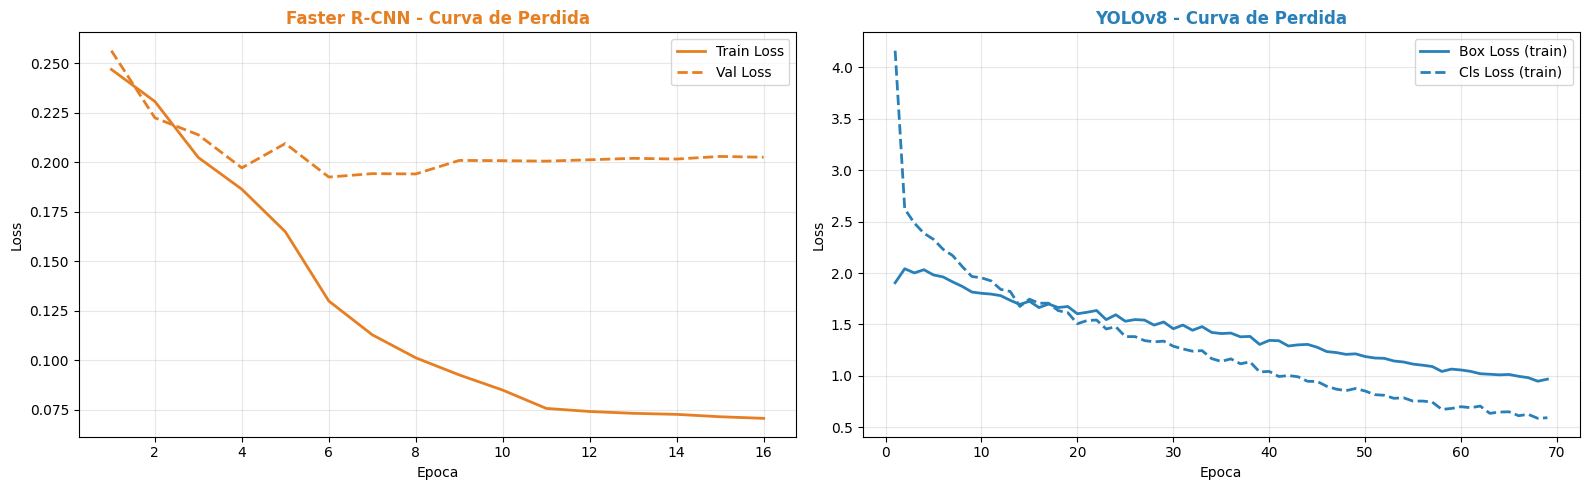

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if df_frcnn_train is not None:
    axes[0].plot(df_frcnn_train['epoch'], df_frcnn_train['train_loss'], color=COLOR_FRCNN, lw=2, label='Train Loss')
    axes[0].plot(df_frcnn_train['epoch'], df_frcnn_train['val_loss'], color=COLOR_FRCNN, lw=2, ls='--', label='Val Loss')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_title('Faster R-CNN - Curva de Perdida', fontweight='bold', color=COLOR_FRCNN)
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

if df_yolo_train is not None:
    cols = df_yolo_train.columns
    box_col = [c for c in cols if 'box_loss' in c and 'train' in c]
    cls_col = [c for c in cols if 'cls_loss' in c and 'train' in c]
    if box_col:
        axes[1].plot(df_yolo_train['epoch'], df_yolo_train[box_col[0]], color=COLOR_YOLO, lw=2, label='Box Loss (train)')
    if cls_col:
        axes[1].plot(df_yolo_train['epoch'], df_yolo_train[cls_col[0]], color=COLOR_YOLO, lw=2, ls='--', label='Cls Loss (train)')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title('YOLOv8 - Curva de Perdida', fontweight='bold', color=COLOR_YOLO)
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Loss'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'curvas_entrenamiento_comparadas.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Evaluación de Faster R-CNN sobre el test set

Se recarga el checkpoint entrenado y se recalculan: **mAP@0.5**, **mAP@0.5:0.95** (con `torchmetrics`, criterio COCO), **IoU medio**, **Precisión/Recall/F1** (con matching manual a IoU > 0.5, igual que en el notebook original), tiempo de inferencia y número de parámetros.

Las clases y el dataset se redefinen aquí para que este notebook sea autónomo (no depende de haber corrido `Faster_RCNN_Training.ipynb` en la misma sesión).

In [6]:
import xml.etree.ElementTree as ET

class BrainTumorVOCDataset(torch.utils.data.Dataset):
    """Identico al usado en Faster_RCNN_Training.ipynb, redefinido aqui para que este notebook sea autonomo."""
    def __init__(self, root_dir, split='train', image_size=832):
        self.split = split
        self.image_size = image_size
        self.images_dir = os.path.join(root_dir, 'images', split)
        self.annotations_dir = os.path.join(root_dir, 'annotations_voc', split)
        self.class_map = {'Glioma': 1, 'Meningioma': 2, 'Pituitary': 3}
        self.imgs = []
        if os.path.exists(self.images_dir):
            for file in os.listdir(self.images_dir):
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.imgs.append(file)
        self.imgs.sort()

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.images_dir, img_name)
        xml_path = os.path.join(self.annotations_dir, os.path.splitext(img_name)[0] + '.xml')

        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        img_tensor = TF.to_tensor(img)

        boxes, labels = [], []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                name = obj.find('name').text
                if name in self.class_map:
                    b = obj.find('bndbox')
                    xmin, ymin = float(b.find('xmin').text), float(b.find('ymin').text)
                    xmax, ymax = float(b.find('xmax').text), float(b.find('ymax').text)
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(self.class_map[name])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return img_tensor, target

    def __len__(self):
        return len(self.imgs)


def collate_fn(batch):
    return tuple(zip(*batch))


def get_faster_rcnn_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def compute_iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / float(areaA + areaB - inter)

In [7]:
frcnn_metrics = {}
frcnn_map_per_class = {}
frcnn_iou_list = []
frcnn_iou_per_class = {c: [] for c in CLASS_NAMES}

if FRCNN_ROOT and DATASET_ROOT:
    ckpt_candidates = glob.glob(os.path.join(FRCNN_ROOT, 'checkpoints', '*.pth'))
    if ckpt_candidates:
        ckpt_path = next((c for c in ckpt_candidates if 'best' in c), ckpt_candidates[0])
        print(f"Cargando checkpoint Faster R-CNN: {ckpt_path}")

        model_frcnn = get_faster_rcnn_model(NUM_CLASSES_FRCNN)
        model_frcnn.load_state_dict(torch.load(ckpt_path, map_location=device))
        model_frcnn.to(device)
        model_frcnn.eval()

        test_dataset = BrainTumorVOCDataset(DATASET_ROOT, split='test')
        test_loader = torch.utils.data.DataLoader(
            test_dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn
        )
        print(f"Evaluando Faster R-CNN sobre {len(test_dataset)} imagenes de test...")

        map_metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

        tp, fp, fn = 0, 0, 0
        tiempos_inferencia = []

        with torch.no_grad():
            for images, targets in test_loader:
                images = [img.to(device) for img in images]

                t0 = time.time()
                preds = model_frcnn(images)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                tiempos_inferencia.append(time.time() - t0)

                preds_tm = [{
                    'boxes': p['boxes'].cpu(),
                    'scores': p['scores'].cpu(),
                    'labels': p['labels'].cpu()
                } for p in preds]
                targets_tm = [{
                    'boxes': t['boxes'].cpu(),
                    'labels': t['labels'].cpu()
                } for t in targets]
                map_metric.update(preds_tm, targets_tm)

                for target, pred in zip(targets, preds):
                    gt_boxes = target['boxes'].cpu().numpy()
                    gt_labels = target['labels'].cpu().numpy()
                    scores = pred['scores'].cpu().numpy()
                    valid = scores > 0.5
                    p_boxes = pred['boxes'].cpu().numpy()[valid]
                    p_labels = pred['labels'].cpu().numpy()[valid]

                    matched_gt = set()
                    for pi, p_box in enumerate(p_boxes):
                        best_iou, best_gi = 0.0, -1
                        for gi, g_box in enumerate(gt_boxes):
                            if gi in matched_gt:
                                continue
                            iou = compute_iou(p_box, g_box)
                            if iou > best_iou:
                                best_iou, best_gi = iou, gi
                        if best_iou > 0.5 and best_gi != -1 and p_labels[pi] == gt_labels[best_gi]:
                            tp += 1
                            matched_gt.add(best_gi)
                            frcnn_iou_list.append(best_iou)
                            frcnn_iou_per_class[CLASS_NAMES[gt_labels[best_gi] - 1]].append(best_iou)
                        else:
                            fp += 1
                    fn += len(gt_boxes) - len(matched_gt)

        result = map_metric.compute()
        precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_manual = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_manual = (2 * precision_manual * recall_manual / (precision_manual + recall_manual)
                     if (precision_manual + recall_manual) > 0 else 0.0)

        frcnn_metrics = {
            'Precision': round(precision_manual, 4),
            'Recall': round(recall_manual, 4),
            'F1-Score': round(f1_manual, 4),
            'mAP@0.5': round(result['map_50'].item(), 4),
            'mAP@0.5:0.95': round(result['map'].item(), 4),
            'Mean IoU': round(float(np.mean(frcnn_iou_list)) if frcnn_iou_list else 0.0, 4),
            'Tiempo inferencia (ms/img)': round(np.mean(tiempos_inferencia) * 1000, 2),
            'N Parametros (M)': round(sum(p.numel() for p in model_frcnn.parameters()) / 1e6, 2),
        }

        if 'classes' in result:
            classes_ids = result['classes'].tolist()
            for i, cid in enumerate(classes_ids):
                cid = int(cid)
                cname = CLASS_NAMES[cid - 1] if 1 <= cid <= len(CLASS_NAMES) else f'clase_{cid}'
                try:
                    frcnn_map_per_class[cname] = round(result['map_per_class'][i].item(), 4)
                except (IndexError, TypeError):
                    frcnn_map_per_class[cname] = None

        print("Metricas Faster R-CNN calculadas:")
        for k, v in frcnn_metrics.items():
            print(f"  {k}: {v}")
    else:
        print("No se encontro ningun checkpoint (.pth) de Faster R-CNN en 'checkpoints/'.")
else:
    print("Faltan rutas de Faster R-CNN o del dataset; no se puede evaluar.")

Cargando checkpoint Faster R-CNN: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Faster_RCNN/checkpoints/faster_rcnn_tumor_best.pth
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 108MB/s] 


Evaluando Faster R-CNN sobre 379 imagenes de test...
Metricas Faster R-CNN calculadas:
  Precision: 0.6676
  Recall: 0.7364
  F1-Score: 0.7003
  mAP@0.5: 0.7169
  mAP@0.5:0.95: 0.343
  Mean IoU: 0.7555
  Tiempo inferencia (ms/img): 91.69
  N Parametros (M): 41.31


## 5. Evaluación de YOLOv8 sobre el test set

Se usa `model.val()` de Ultralytics para las métricas nativas (Precision, Recall, mAP@0.5, mAP@0.5:0.95 por clase y globales — criterio COCO estándar), y se recalcula el **IoU medio** con el mismo criterio y umbral (score/conf > 0.5) usado para Faster R-CNN, para que la comparación de IoU sea justa entre ambos modelos.

In [8]:
def yolo_a_xyxy(x_centro, y_centro, ancho, alto, img_w, img_h):
    return [
        (x_centro - ancho / 2) * img_w, (y_centro - alto / 2) * img_h,
        (x_centro + ancho / 2) * img_w, (y_centro + alto / 2) * img_h
    ]

yolo_metrics = {}
yolo_map_per_class = {}
yolo_iou_list = []
yolo_iou_per_class = {c: [] for c in CLASS_NAMES}

if YOLO_ROOT and RUTA_YAML and os.path.exists(RUTA_YAML):
    best_candidates = glob.glob(os.path.join(YOLO_ROOT, '**', 'best.pt'), recursive=True)
    if best_candidates:
        best_pt = best_candidates[0]
        print(f"Cargando checkpoint YOLOv8: {best_pt}")
        model_yolo = YOLO(best_pt)
        device_yolo = 0 if torch.cuda.is_available() else 'cpu'

        metricas = model_yolo.val(data=RUTA_YAML, split='test', device=device_yolo, verbose=False)
        n_params_yolo = sum(p.numel() for p in model_yolo.model.parameters())

        mp_, mr_ = float(metricas.box.mp), float(metricas.box.mr)
        yolo_metrics = {
            'Precision': round(mp_, 4),
            'Recall': round(mr_, 4),
            'F1-Score': round(2 * mp_ * mr_ / (mp_ + mr_), 4) if (mp_ + mr_) > 0 else 0.0,
            'mAP@0.5': round(float(metricas.box.map50), 4),
            'mAP@0.5:0.95': round(float(metricas.box.map), 4),
            'N Parametros (M)': round(n_params_yolo / 1e6, 2),
        }

        for i, cname in enumerate(CLASS_NAMES):
            try:
                yolo_map_per_class[cname] = round(float(metricas.box.class_result(i)[2]), 4)
            except Exception:
                yolo_map_per_class[cname] = None

        ruta_test_imgs = os.path.join(DATASET_ROOT, 'images', 'test')
        ruta_test_labels = os.path.join(DATASET_ROOT, 'labels', 'test')
        tiempos_yolo = []

        if os.path.exists(ruta_test_labels):
            for archivo_txt in sorted(os.listdir(ruta_test_labels)):
                if not archivo_txt.endswith('.txt'):
                    continue
                nombre_base = archivo_txt.replace('.txt', '')
                ruta_img = None
                for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
                    candidato = os.path.join(ruta_test_imgs, nombre_base + ext)
                    if os.path.exists(candidato):
                        ruta_img = candidato
                        break
                if ruta_img is None:
                    continue

                img = Image.open(ruta_img)
                img_w, img_h = img.size

                gt_boxes, gt_labels = [], []
                with open(os.path.join(ruta_test_labels, archivo_txt), 'r') as f:
                    for linea in f.readlines():
                        partes = linea.strip().split()
                        if len(partes) == 0:
                            continue
                        cls_id, xc, yc, w, h = map(float, partes)
                        gt_boxes.append(yolo_a_xyxy(xc, yc, w, h, img_w, img_h))
                        gt_labels.append(int(cls_id))

                if len(gt_boxes) == 0:
                    continue

                t0 = time.time()
                pred = model_yolo.predict(source=ruta_img, device=device_yolo, conf=0.5, save=False, verbose=False)
                tiempos_yolo.append(time.time() - t0)

                pred_boxes = pred[0].boxes.xyxy.cpu().numpy()
                pred_labels = pred[0].boxes.cls.cpu().numpy().astype(int)

                matched = set()
                for p_box, p_lbl in zip(pred_boxes, pred_labels):
                    best_iou, best_gi = 0.0, -1
                    for gi, g_box in enumerate(gt_boxes):
                        if gi in matched:
                            continue
                        iou = compute_iou(p_box, g_box)
                        if iou > best_iou:
                            best_iou, best_gi = iou, gi
                    if best_iou > 0.5 and best_gi != -1 and gt_labels[best_gi] == p_lbl:
                        yolo_iou_list.append(best_iou)
                        yolo_iou_per_class[CLASS_NAMES[p_lbl]].append(best_iou)
                        matched.add(best_gi)

            yolo_metrics['Mean IoU'] = round(float(np.mean(yolo_iou_list)) if yolo_iou_list else 0.0, 4)
            yolo_metrics['Tiempo inferencia (ms/img)'] = round(np.mean(tiempos_yolo) * 1000, 2) if tiempos_yolo else None
        else:
            print("No se encontro la carpeta de labels de test para calcular IoU de YOLO.")

        print("Metricas YOLOv8 calculadas:")
        for k, v in yolo_metrics.items():
            print(f"  {k}: {v}")
    else:
        print("No se encontro ningun checkpoint 'best.pt' de YOLOv8.")
else:
    print("Faltan rutas de YOLOv8 o el dataset.yaml; no se puede evaluar.")

Cargando checkpoint YOLOv8: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/yolov8s.pt/weights/best.pt
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 40.3±17.1 MB/s, size: 144.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test... 379 images, 49 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 379/379 3.1it/s 2:03
val: New cache created: /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.3it/s 10.3s
                   all        379        330      0.895      0.864     

## 6. Tabla comparativa unificada

> **Nota metodológica:** Precision/Recall/F1 de YOLOv8 provienen del cálculo nativo de Ultralytics (agregado sobre la curva de confianza, criterio estándar de la librería). Los de Faster R-CNN se calculan aquí manualmente con un umbral fijo de score > 0.5 e IoU > 0.5, ya que `torchvision` no expone esa métrica directamente. El **mAP** de ambos sí usa el mismo criterio COCO (vía `torchmetrics` para Faster R-CNN y Ultralytics nativo para YOLO, que también sigue el estándar COCO), por lo que esa comparación es directa.

In [9]:
all_metric_names = ['Precision', 'Recall', 'F1-Score', 'mAP@0.5', 'mAP@0.5:0.95',
                     'Mean IoU', 'Tiempo inferencia (ms/img)', 'N Parametros (M)']

comparison_rows = [
    {'Metrica': m, 'Faster R-CNN': frcnn_metrics.get(m, 'N/A'), 'YOLOv8': yolo_metrics.get(m, 'N/A')}
    for m in all_metric_names
]
df_comparacion = pd.DataFrame(comparison_rows)
display(df_comparacion)

df_clases_comp = pd.DataFrame({
    'Clase': CLASS_NAMES,
    'mAP@0.5 Faster R-CNN': [frcnn_map_per_class.get(c, 'N/A') for c in CLASS_NAMES],
    'mAP@0.5 YOLOv8': [yolo_map_per_class.get(c, 'N/A') for c in CLASS_NAMES],
})
display(df_clases_comp)

metrics_dir = os.path.join(COMPARISON_ROOT, 'metrics')
df_comparacion.to_csv(os.path.join(metrics_dir, 'comparacion_global.csv'), index=False)
df_clases_comp.to_csv(os.path.join(metrics_dir, 'comparacion_por_clase.csv'), index=False)
print(f"\nTablas guardadas en: {metrics_dir}")

,Metrica,Faster R-CNN,YOLOv8
0,Precision,0.6676,0.8952
1,Recall,0.7364,0.8641
2,F1-Score,0.7003,0.8794
3,mAP@0.5,0.7169,0.9284
4,mAP@0.5:0.95,0.3430,0.7343
5,Mean IoU,0.7555,0.8914
6,Tiempo inferencia (ms/img),91.6900,25.4500
7,N Parametros (M),41.3100,11.1300


,Clase,mAP@0.5 Faster R-CNN,mAP@0.5 YOLOv8
0,Glioma,0.2432,0.8739
1,Meningioma,0.4078,0.9426
2,Pituitary,0.3779,0.9687



Tablas guardadas en: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_Comparacion/metrics


## 7. Visualizaciones comparativas

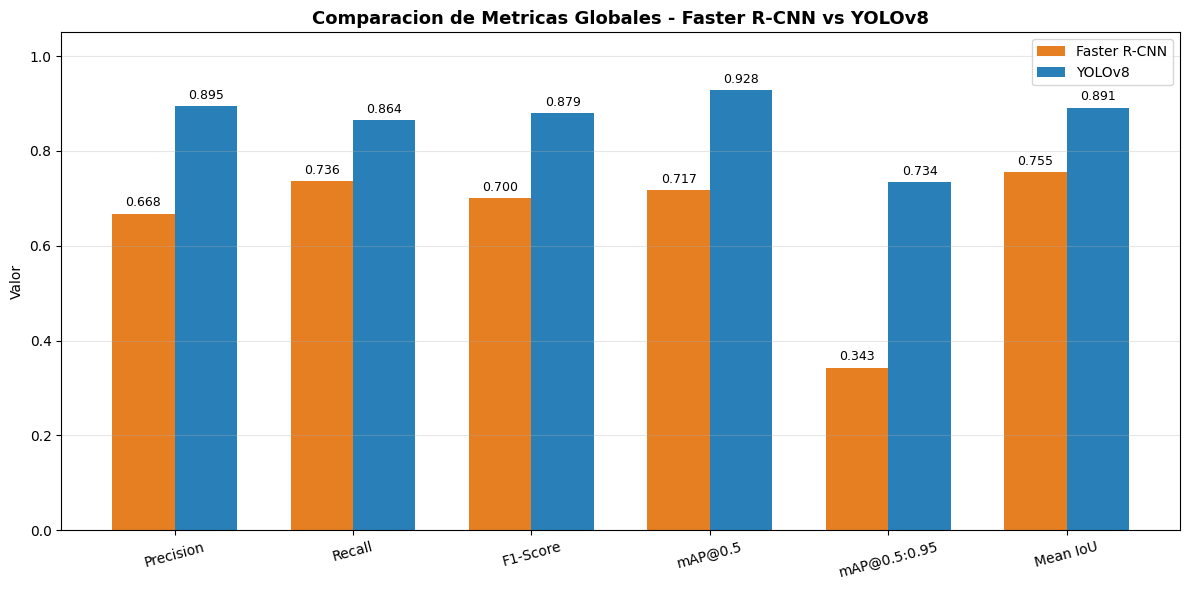

In [10]:
metrics_bar = ['Precision', 'Recall', 'F1-Score', 'mAP@0.5', 'mAP@0.5:0.95', 'Mean IoU']
frcnn_vals = [frcnn_metrics.get(m, 0) or 0 for m in metrics_bar]
yolo_vals = [yolo_metrics.get(m, 0) or 0 for m in metrics_bar]

x = np.arange(len(metrics_bar))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, frcnn_vals, width, label='Faster R-CNN', color=COLOR_FRCNN)
b2 = ax.bar(x + width/2, yolo_vals, width, label='YOLOv8', color=COLOR_YOLO)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics_bar, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor')
ax.set_title('Comparacion de Metricas Globales - Faster R-CNN vs YOLOv8', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'metricas_globales_comparadas.png'), dpi=300, bbox_inches='tight')
plt.show()

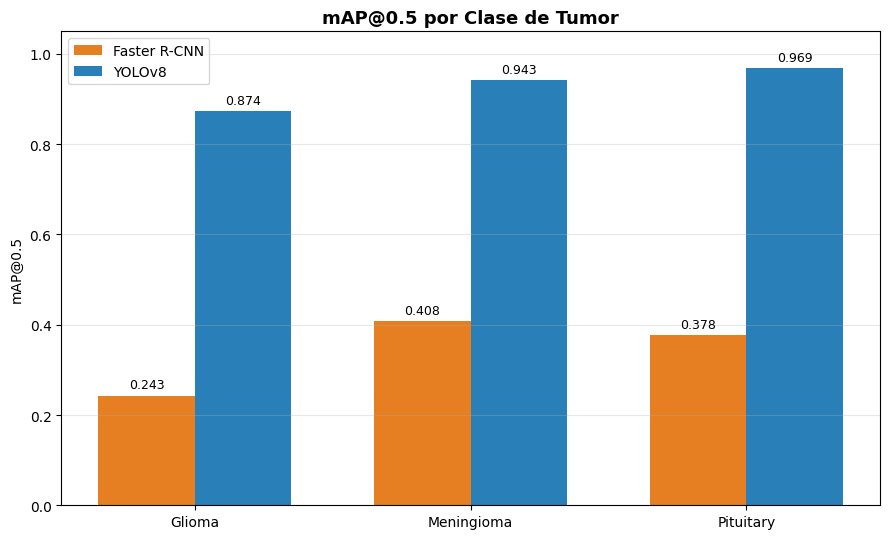

In [11]:
x = np.arange(len(CLASS_NAMES))
frcnn_cls_vals = [frcnn_map_per_class.get(c, 0) or 0 for c in CLASS_NAMES]
yolo_cls_vals = [yolo_map_per_class.get(c, 0) or 0 for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - width/2, frcnn_cls_vals, width, label='Faster R-CNN', color=COLOR_FRCNN)
b2 = ax.bar(x + width/2, yolo_cls_vals, width, label='YOLOv8', color=COLOR_YOLO)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05)
ax.set_ylabel('mAP@0.5')
ax.set_title('mAP@0.5 por Clase de Tumor', fontweight='bold', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'map_por_clase_comparado.png'), dpi=300, bbox_inches='tight')
plt.show()

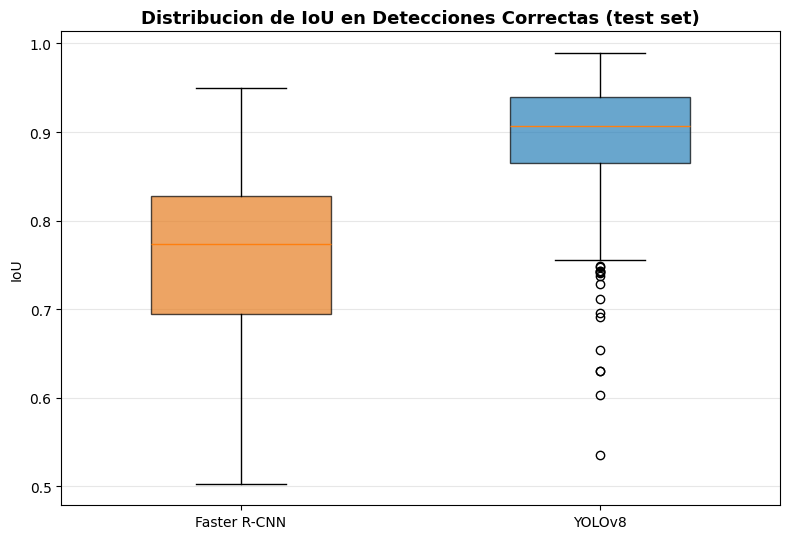

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
data_iou = [frcnn_iou_list if frcnn_iou_list else [0], yolo_iou_list if yolo_iou_list else [0]]
bp = ax.boxplot(data_iou, tick_labels=['Faster R-CNN', 'YOLOv8'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [COLOR_FRCNN, COLOR_YOLO]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('IoU')
ax.set_title('Distribucion de IoU en Detecciones Correctas (test set)', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'distribucion_iou_comparada.png'), dpi=300, bbox_inches='tight')
plt.show()

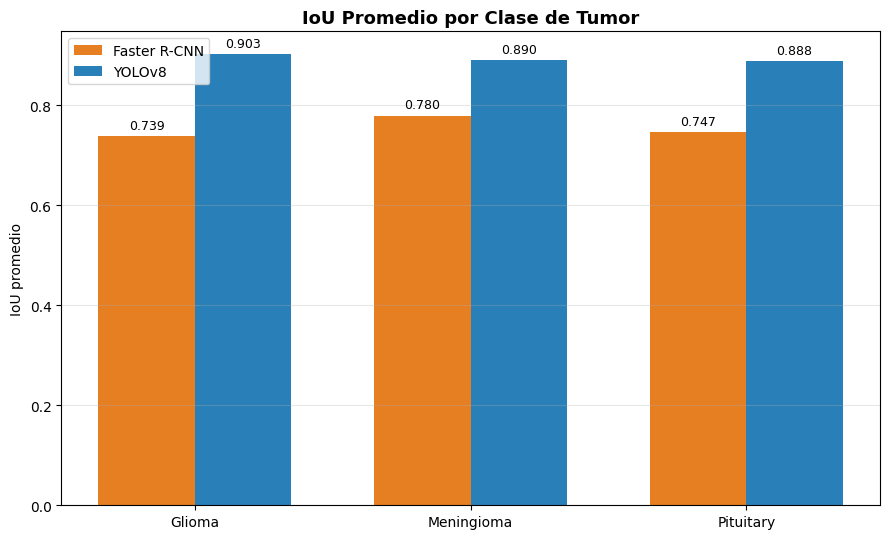

In [13]:
frcnn_iou_cls_means = [np.mean(frcnn_iou_per_class[c]) if frcnn_iou_per_class[c] else 0 for c in CLASS_NAMES]
yolo_iou_cls_means = [np.mean(yolo_iou_per_class[c]) if yolo_iou_per_class[c] else 0 for c in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - width/2, frcnn_iou_cls_means, width, label='Faster R-CNN', color=COLOR_FRCNN)
b2 = ax.bar(x + width/2, yolo_iou_cls_means, width, label='YOLOv8', color=COLOR_YOLO)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('IoU promedio')
ax.set_title('IoU Promedio por Clase de Tumor', fontweight='bold', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'iou_por_clase_comparado.png'), dpi=300, bbox_inches='tight')
plt.show()

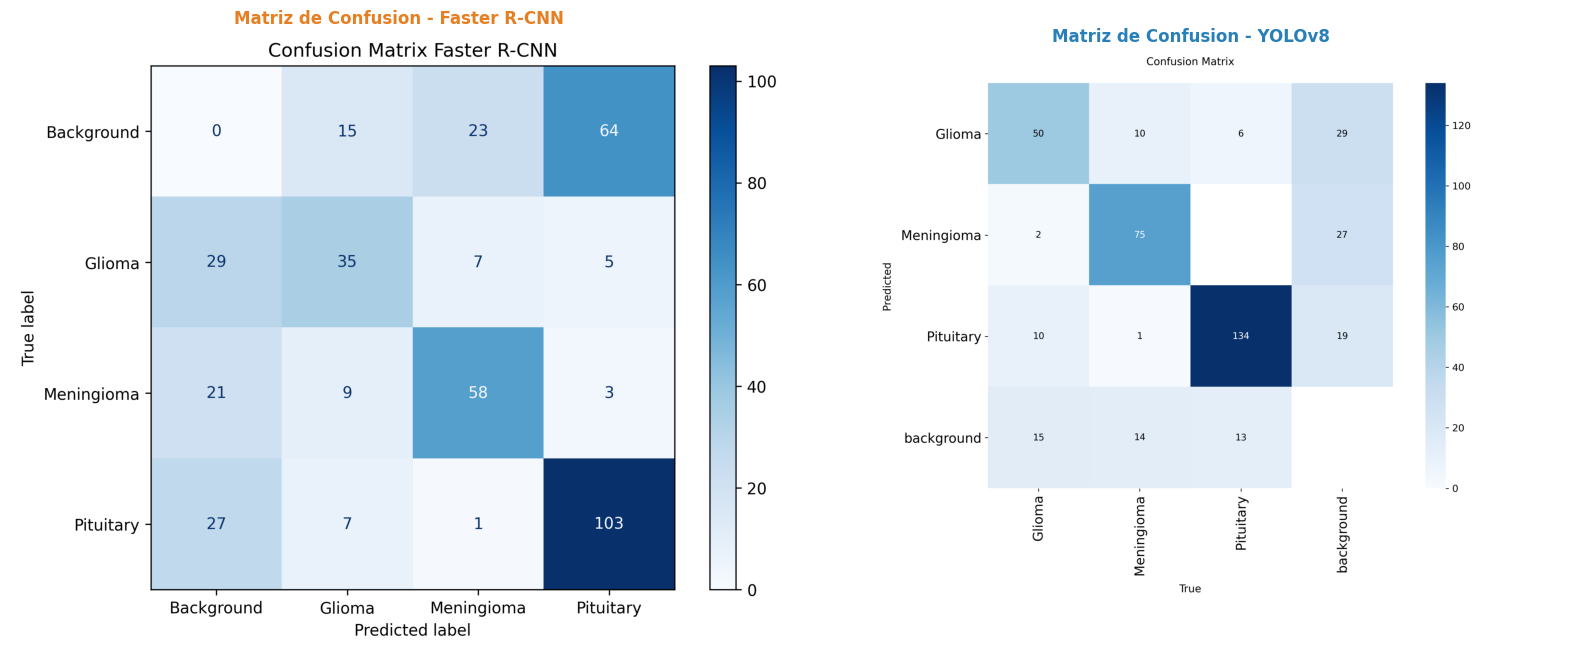

In [14]:
frcnn_cm_path = os.path.join(FRCNN_ROOT, 'plots', 'confusion_matrix.png') if FRCNN_ROOT else None
yolo_cm_candidates = glob.glob(os.path.join(YOLO_ROOT, '**', 'confusion_matrix.png'), recursive=True) if YOLO_ROOT else []
yolo_cm_path = yolo_cm_candidates[0] if yolo_cm_candidates else None

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
if frcnn_cm_path and os.path.exists(frcnn_cm_path):
    axes[0].imshow(mpimg.imread(frcnn_cm_path))
else:
    axes[0].text(0.5, 0.5, 'No disponible', ha='center', va='center')
axes[0].set_title('Matriz de Confusion - Faster R-CNN', fontweight='bold', color=COLOR_FRCNN)
axes[0].axis('off')

if yolo_cm_path and os.path.exists(yolo_cm_path):
    axes[1].imshow(mpimg.imread(yolo_cm_path))
else:
    axes[1].text(0.5, 0.5, 'No disponible', ha='center', va='center')
axes[1].set_title('Matriz de Confusion - YOLOv8', fontweight='bold', color=COLOR_YOLO)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'matrices_confusion_comparadas.png'), dpi=200, bbox_inches='tight')
plt.show()

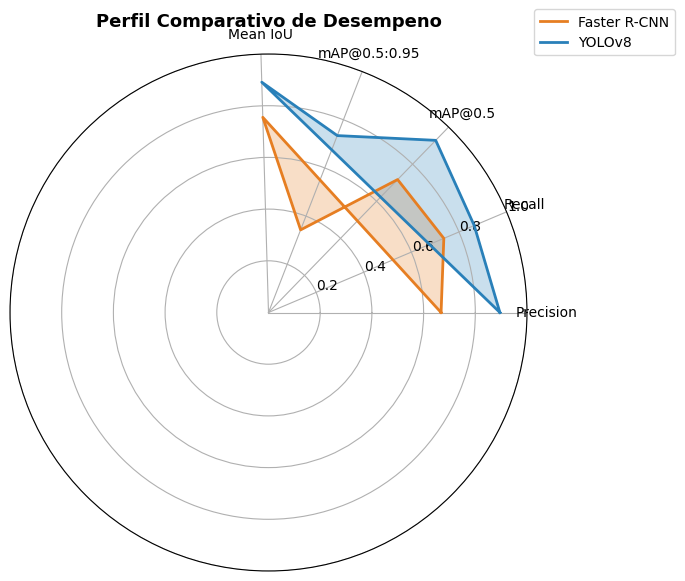

In [15]:
radar_metrics = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95', 'Mean IoU']
frcnn_radar = [frcnn_metrics.get(m, 0) or 0 for m in radar_metrics]
yolo_radar = [yolo_metrics.get(m, 0) or 0 for m in radar_metrics]

angles = [n / float(len(radar_metrics)) * 2 * pi for n in range(len(radar_metrics))]
angles += angles[:1]
frcnn_radar += frcnn_radar[:1]
yolo_radar += yolo_radar[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, frcnn_radar, color=COLOR_FRCNN, linewidth=2, label='Faster R-CNN')
ax.fill(angles, frcnn_radar, color=COLOR_FRCNN, alpha=0.25)
ax.plot(angles, yolo_radar, color=COLOR_YOLO, linewidth=2, label='YOLOv8')
ax.fill(angles, yolo_radar, color=COLOR_YOLO, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_ylim(0, 1)
ax.set_title('Perfil Comparativo de Desempeno', fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'radar_comparativo.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Complejidad del modelo y velocidad de inferencia

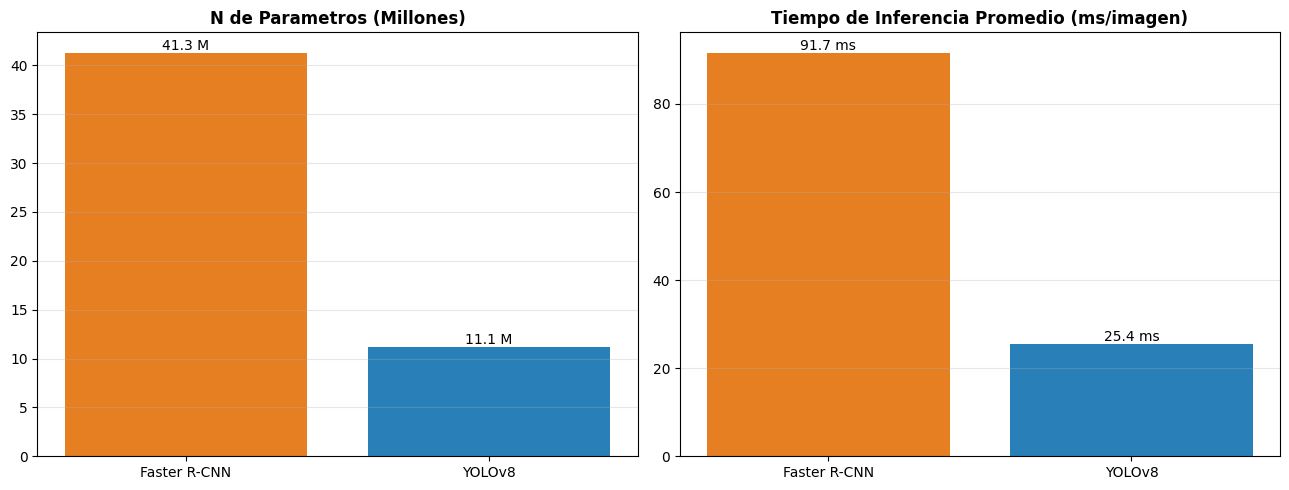

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos = ['Faster R-CNN', 'YOLOv8']
params = [frcnn_metrics.get('N Parametros (M)', 0) or 0, yolo_metrics.get('N Parametros (M)', 0) or 0]
tiempos = [frcnn_metrics.get('Tiempo inferencia (ms/img)', 0) or 0, yolo_metrics.get('Tiempo inferencia (ms/img)', 0) or 0]

b1 = axes[0].bar(modelos, params, color=[COLOR_FRCNN, COLOR_YOLO])
axes[0].bar_label(b1, fmt='%.1f M')
axes[0].set_title('N de Parametros (Millones)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

b2 = axes[1].bar(modelos, tiempos, color=[COLOR_FRCNN, COLOR_YOLO])
axes[1].bar_label(b2, fmt='%.1f ms')
axes[1].set_title('Tiempo de Inferencia Promedio (ms/imagen)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_ROOT, 'plots', 'complejidad_velocidad_comparada.png'), dpi=300, bbox_inches='tight')
plt.show()

## 9. Resumen comparativo automático

In [17]:
print("="*60)
print("   RESUMEN COMPARATIVO AUTOMATICO")
print("="*60)

def mejor(metric, higher_is_better=True):
    f = frcnn_metrics.get(metric)
    y = yolo_metrics.get(metric)
    if f is None or y is None:
        return "N/A"
    if higher_is_better:
        return "Faster R-CNN" if f > y else ("YOLOv8" if y > f else "Empate")
    else:
        return "Faster R-CNN" if f < y else ("YOLOv8" if y < f else "Empate")

resumen = {
    'mAP@0.5 mas alto': mejor('mAP@0.5'),
    'mAP@0.5:0.95 mas alto': mejor('mAP@0.5:0.95'),
    'Mean IoU mas alto': mejor('Mean IoU'),
    'Precision mas alta': mejor('Precision'),
    'Recall mas alto': mejor('Recall'),
    'Inferencia mas rapida': mejor('Tiempo inferencia (ms/img)', higher_is_better=False),
    'Modelo mas liviano': mejor('N Parametros (M)', higher_is_better=False),
}

for k, v in resumen.items():
    print(f"  - {k}: {v}")

print()
print("Nota: este resumen es orientativo y se basa unicamente en las metricas")
print("calculadas arriba. La eleccion final del modelo debe considerar tambien")
print("el contexto de uso (recursos disponibles, necesidad de velocidad vs precision, etc).")

   RESUMEN COMPARATIVO AUTOMATICO
  - mAP@0.5 mas alto: YOLOv8
  - mAP@0.5:0.95 mas alto: YOLOv8
  - Mean IoU mas alto: YOLOv8
  - Precision mas alta: YOLOv8
  - Recall mas alto: YOLOv8
  - Inferencia mas rapida: YOLOv8
  - Modelo mas liviano: YOLOv8

Nota: este resumen es orientativo y se basa unicamente en las metricas
calculadas arriba. La eleccion final del modelo debe considerar tambien
el contexto de uso (recursos disponibles, necesidad de velocidad vs precision, etc).
